**File:** `historical_scheme_data.csv`


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', 60)

In [2]:
schemes = pd.read_csv('../data/processed/historical_scheme_data.csv')
print("Shape:", schemes.shape)

Shape: (800, 16)


## 3.1 Price, Plot size & Monthly EMI distribution

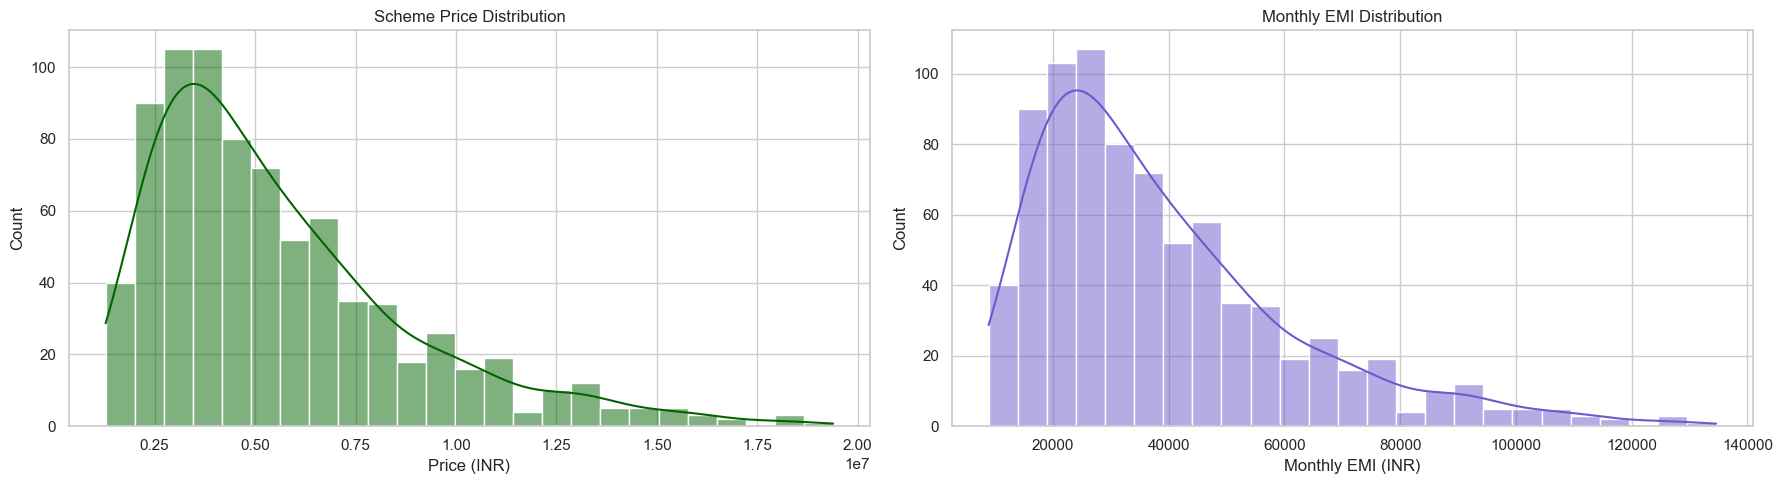

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
# Plot 1: Price Distribution
sns.histplot(schemes['Price_INR'], bins=25, kde=True, color='darkgreen', ax=axes[0])
axes[0].set_title('Scheme Price Distribution')
axes[0].set_xlabel('Price (INR)')
# Plot 2: Monthly EMI Distribution
sns.histplot(schemes['Monthly_EMI_INR'], bins=25, kde=True, color='slateblue', ax=axes[1])
axes[1].set_title('Monthly EMI Distribution')
axes[1].set_xlabel('Monthly EMI (INR)')
plt.savefig('../reports/figures/price-plot_size-monthly_emi.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

## 3.2 Plot size vs Price relationship

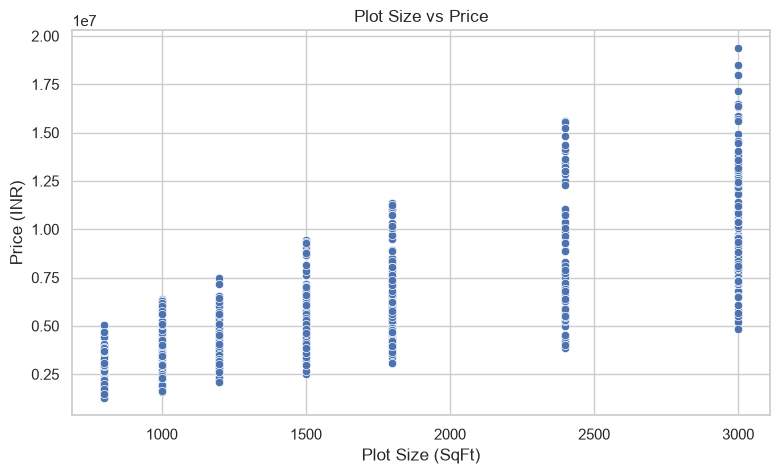

In [5]:
plt.figure()
sns.scatterplot(data=schemes, x='Plot_Size_SqFt', y='Price_INR')
plt.title('Plot Size vs Price')
plt.xlabel('Plot Size (SqFt)')
plt.ylabel('Price (INR)')
plt.savefig('../reports/figures/plot_size-vs-price.png', dpi=300, bbox_inches='tight')
plt.show()


## 3.3 Demand level & Success score 

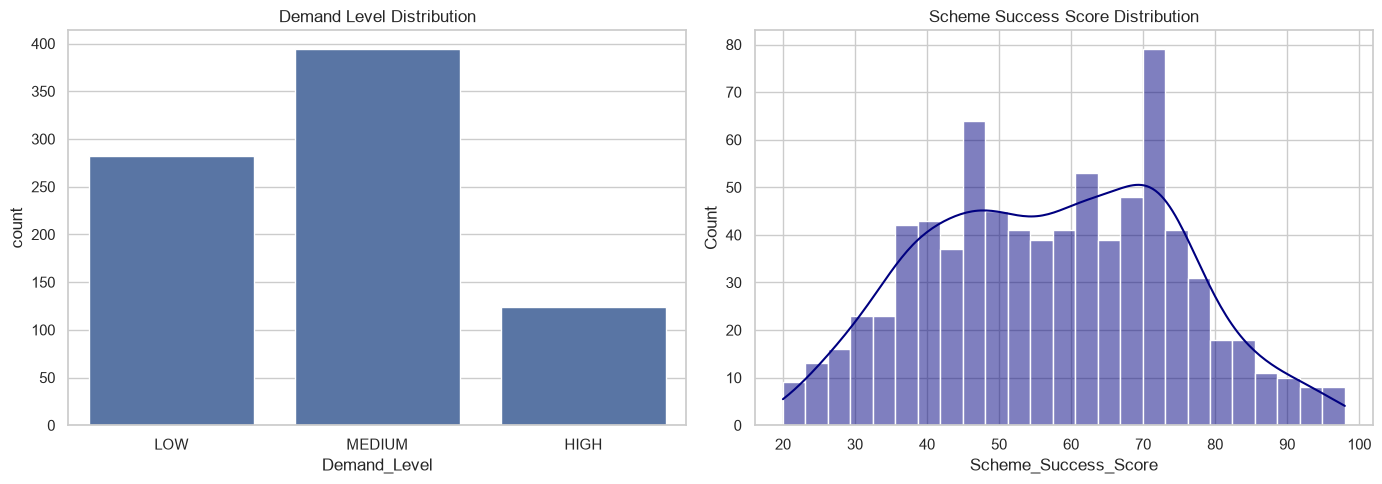

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=schemes, x='Demand_Level', order=['LOW', 'MEDIUM', 'HIGH'], ax=axes[0])
axes[0].set_title('Demand Level Distribution')

sns.histplot(schemes['Scheme_Success_Score'], bins=25, kde=True, ax=axes[1], color='navy')
axes[1].set_title('Scheme Success Score Distribution')

plt.savefig('../reports/figures/demand_level-success_score.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


## 3.4 Advertising budget vs Leads and Bookings

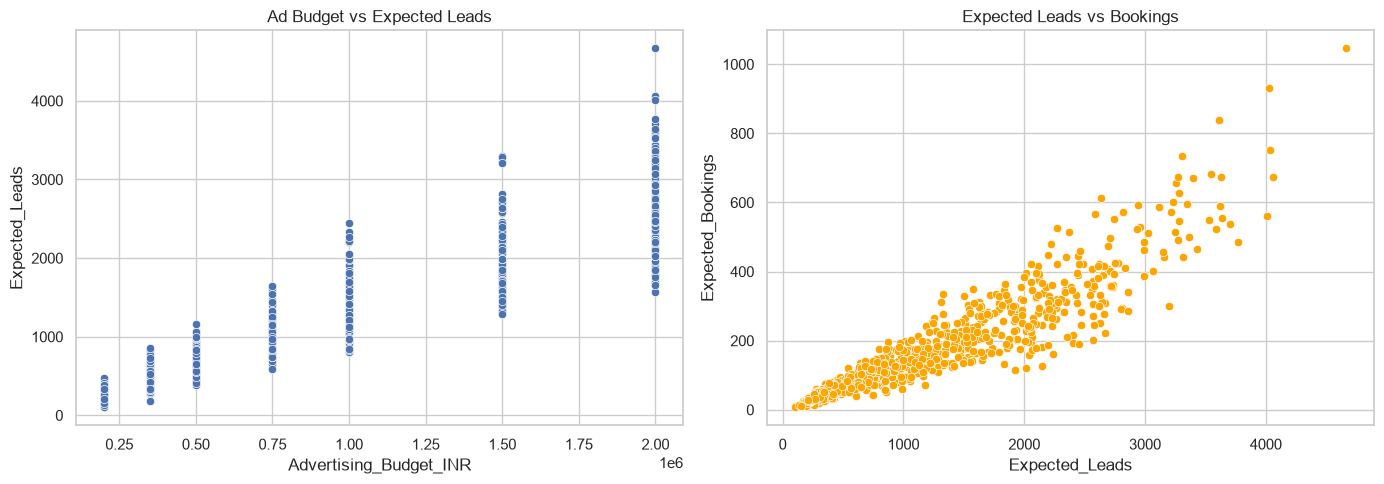

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=schemes, x='Advertising_Budget_INR', y='Expected_Leads', ax=axes[0])
axes[0].set_title('Ad Budget vs Expected Leads')

sns.scatterplot(data=schemes, x='Expected_Leads', y='Expected_Bookings', ax=axes[1], color='orange')
axes[1].set_title('Expected Leads vs Bookings')

plt.savefig('../reports/figures/budget-vs-leads-&-booking.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


## 3.5 Amenities : Park & Clubhouse



In [9]:
park_success = schemes.groupby('Park')['Scheme_Success_Score'].mean()
clubhouse_success = schemes.groupby('Clubhouse')['Scheme_Success_Score'].mean()

print("Average success score by Park:")
print(park_success.round(1))
print()
print("Average success score by Clubhouse:")
print(clubhouse_success.round(1))


Average success score by Park:
Park
No     55.2
Yes    61.0
Name: Scheme_Success_Score, dtype: float64

Average success score by Clubhouse:
Clubhouse
No     53.2
Yes    72.0
Name: Scheme_Success_Score, dtype: float64


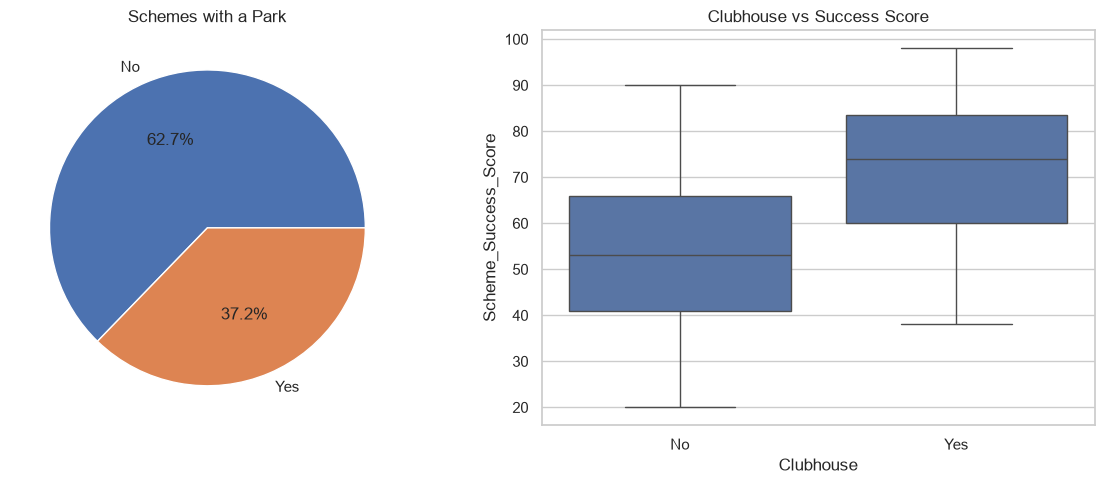

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

park_counts = schemes['Park'].value_counts()
axes[0].pie(park_counts, labels=park_counts.index, autopct='%1.1f%%')
axes[0].set_title('Schemes with a Park')

sns.boxplot(data=schemes, x='Clubhouse', y='Scheme_Success_Score', ax=axes[1])
axes[1].set_title('Clubhouse vs Success Score')

plt.savefig('../reports/figures/amenities-park-&-clubhouse.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


## 3.6 Target age group & most likely buyer segments

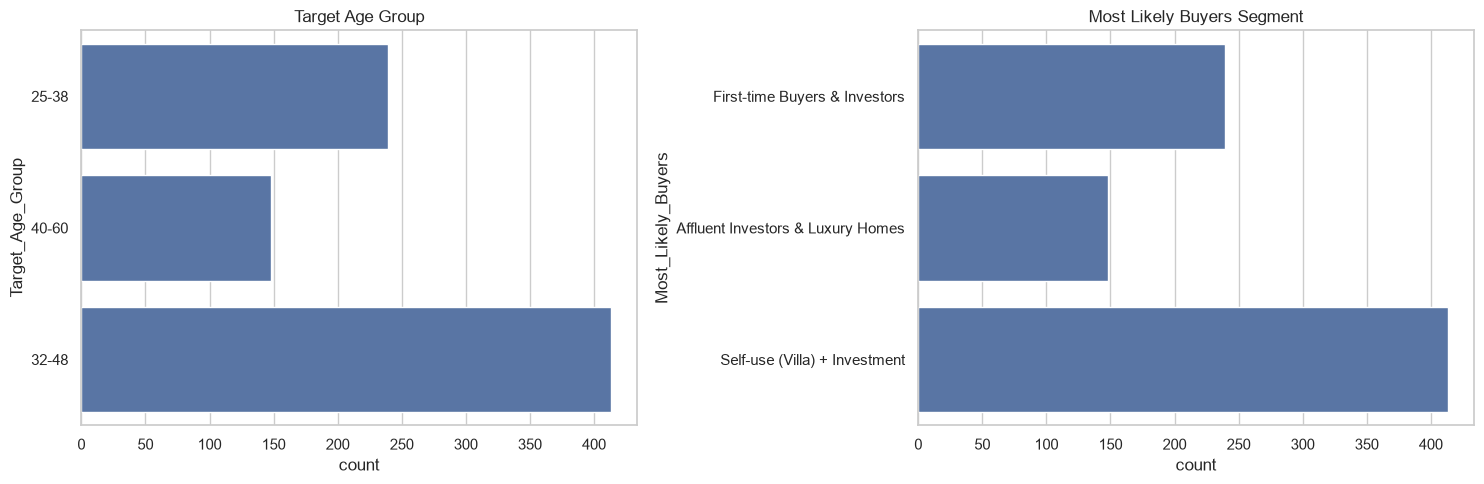

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=schemes, y='Target_Age_Group', ax=axes[0])
axes[0].set_title('Target Age Group')

sns.countplot(data=schemes, y='Most_Likely_Buyers', ax=axes[1])
axes[1].set_title('Most Likely Buyers Segment')

plt.savefig('../reports/figures/target_age-&-buyers.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


## 3.7 Correlation heatmap (numeric features)

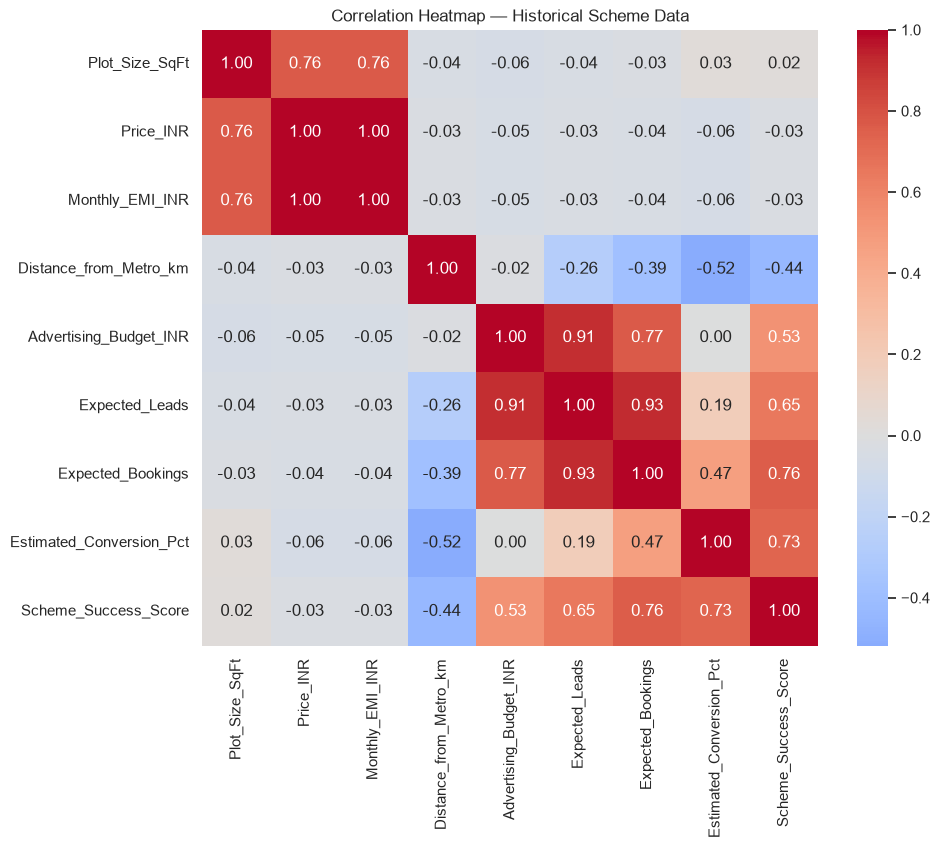

In [13]:
numeric_cols = schemes.select_dtypes(include='number').columns
corr = schemes[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', square=True)
plt.title('Correlation Heatmap — Historical Scheme Data')
plt.savefig('../reports/figures/heatmap(scheme).png', dpi=300, bbox_inches='tight')
plt.show()


## > Key Takeaways from given graphs

1. Price, Plot size and Emi distribution
 >Both scheme price and monthly EMI are right-skewed, with most schemes priced between ₹25–50 lakhs and EMIs concentrated in the ₹20,000–40,000 range.
2. Plot size and price relationship
 >Price generally increases with plot size, but the relationship isn't strict — plot sizes are clustered at fixed values rather than continuous, suggesting standardized plot categories.
3. Demand level and Success realtionship
 >Scheme success scores are broadly spread with a slight bimodal pattern peaks i.e. near 45–50 and 65–75, suggesting two distinct clusters of scheme performance rather than one uniform trend.
4. Advertising Budget and lead relationship
 >Advertising budget shows a strong positive relationship with expected leads, though variance increases sharply at higher budgets (₹1.5M–2M), meaning returns become less predictable at scale. Expected leads and bookings are also strongly correlated.
5. Amenties and Sucess score relationship
 >schemes with a clubhouse show a noticeably higher median success score compared to those without, suggesting clubhouse presence is strongly associated with better scheme performance.
6. Age group buyer intent
 >The 32-48 age group is the largest target segment, followed by 25-38, while 40-60 is the smallest — marketing should prioritize the younger-to-mid age brackets.Self-use (Villa) and for Investment is the dominant buyer segment, closely aligning with the 32-48 age group's size, suggesting this is the primary customer profile to target.